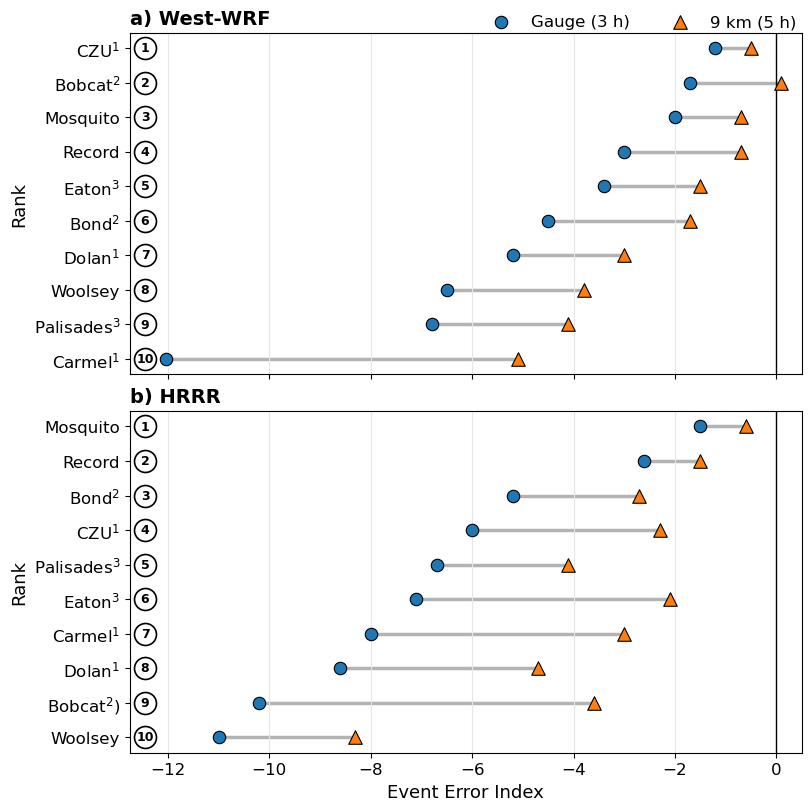

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Data
# ==========================================================

west_events = [
    "CZU$^{1}$",
    "Bobcat$^{2}$",
    "Mosquito",
    "Record",
    "Eaton$^{3}$",
    "Bond$^{2}$",
    "Dolan$^{1}$",
    "Woolsey",
    "Palisades$^{3}$",
    "Carmel$^{1}$"
]

west_gauge = np.array([
    -1.2,
    -1.7,
    -2.0,
    -3.0,
    -3.4,
    -4.5,
    -5.2,
    -6.5,
    -6.8,
    -12.03
])

west_9km = np.array([
    -0.5,
     0.1,
    -0.7,
    -0.7,
    -1.5,
    -1.7,
    -3.0,
    -3.8,
    -4.1,
    -5.1
])


hrrr_events = [
    "Mosquito",
    "Record",
    "Bond$^{2}$",
    "CZU$^{1}$",
    "Palisades$^{3}$",
    "Eaton$^{3}$",
    "Carmel$^{1}$",
    "Dolan$^{1}$",
    "Bobcat$^{2}$)",
    "Woolsey"
]

hrrr_gauge = np.array([
    -1.5,
    -2.6,
    -5.2,
    -6.0,
    -6.7,
    -7.1,
    -8.0,
    -8.6,
    -10.2,
    -11.0
])

hrrr_9km = np.array([
    -0.6,
    -1.5,
    -2.7,
    -2.3,
    -4.1,
    -2.1,
    -3.0,
    -4.7,
    -3.6,
    -8.3
])

# ==========================================================
# Plotting function
# ==========================================================

def plot_panel(ax, events, gauge, grid, title):

    y = np.arange(len(events))[::-1]

    # connector
    for yi, g, n in zip(y, gauge, grid):
        ax.plot([g, n], [yi, yi],
                color='0.7',
                lw=2.5,
                zorder=1)

    # markers
    ax.scatter(gauge,
               y,
               s=80,
               marker='o',
               edgecolor='black',
               linewidth=0.8,
               label='Gauge (3 h)',
               zorder=3)

    ax.scatter(grid,
               y,
               s=95,
               marker='^',
               edgecolor='black',
               linewidth=0.8,
               label='9 km (5 h)',
               zorder=4)

    ax.set_yticks(y)
    ax.set_yticklabels(events)
    ax.set_ylabel("Rank", fontsize=13)

    rank_x = -12.45

    for rank, yi in enumerate(y, start=1):
    
        ax.scatter(
            rank_x,
            yi,
            s=250,
            facecolors='white',
            edgecolors='black',
            linewidth=1.2,
            zorder=5,
            clip_on=False
        )
    
        ax.text(
            rank_x,
            yi,
            str(rank),
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            zorder=6
        )

    ax.set_title(title,
                 fontsize=14,
                 loc='left',
                 fontweight='bold')

    ax.grid(axis='x',
            color='0.9')

    ax.axvline(0,
               color='k',
               lw=1)

    ax.set_xlim(-12.75,0.5)
    ax.tick_params(labelsize=12)

# ==========================================================
# Figure
# ==========================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(8,8),
    sharex=True,
    constrained_layout=True
)

plot_panel(
    axs[0],
    west_events,
    west_gauge,
    west_9km,
    "a) West-WRF"
)

plot_panel(
    axs[1],
    hrrr_events,
    hrrr_gauge,
    hrrr_9km,
    "b) HRRR"
)

axs[1].set_xlabel("Event Error Index", fontsize=13)

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles[:2],
           labels[:2],
           ncol=2,
           loc='upper right',
           frameon=False,
           fontsize=12)

plt.show()

fig.savefig(
        'summary_fig_3km',
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )